#Pytorch Computer Vision
* `torch.vision` : https://www.learnpytorch.io/03_pytorch_computer_vision/
* `tourchvision.datasets` get datasets and data loading function  for computer from here
* `torchvision.models` - get oretrained computer vision models that you leverage for your own problems
* `tochvision.transforms` functions for manipulatinf the vision data to be suitable for use with ML model
* `torch.utils.data.Dataset` Base dataset class for Pytorch
* `torch.utils.data.DataLoader` - Creates a python iterable over a dataset

In [1]:
import torch
from torch import nn

import pandas as pd
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor


import matplotlib.pyplot as plt


In [2]:
##Training Data
train_data = datasets.FashionMNIST(
  root = "data", #Where to download the data to ?
  train = True, #get training data
  download = True, #download data if it doesn't exist
  transform=ToTensor(), #convert to tensor
  target_transform=None
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.1MB/s]


In [3]:
#Testing Data
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform=None
)


In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
##See the first training example
image , label = train_data[0]
image , label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [6]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [8]:
image.shape ,  label

(torch.Size([1, 28, 28]), 9)

Image Shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

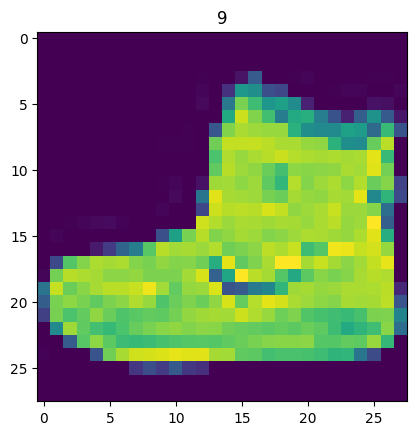

In [9]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image Shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

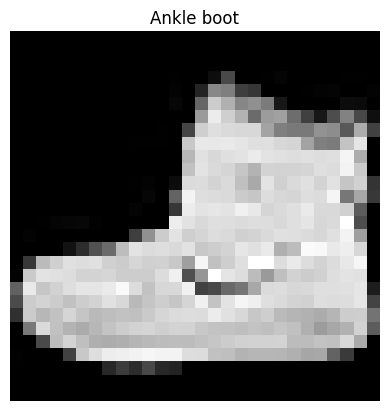

In [10]:
plt.imshow(image.squeeze(),cmap ="gray")
plt.title(class_names[label]);
plt.axis(False);

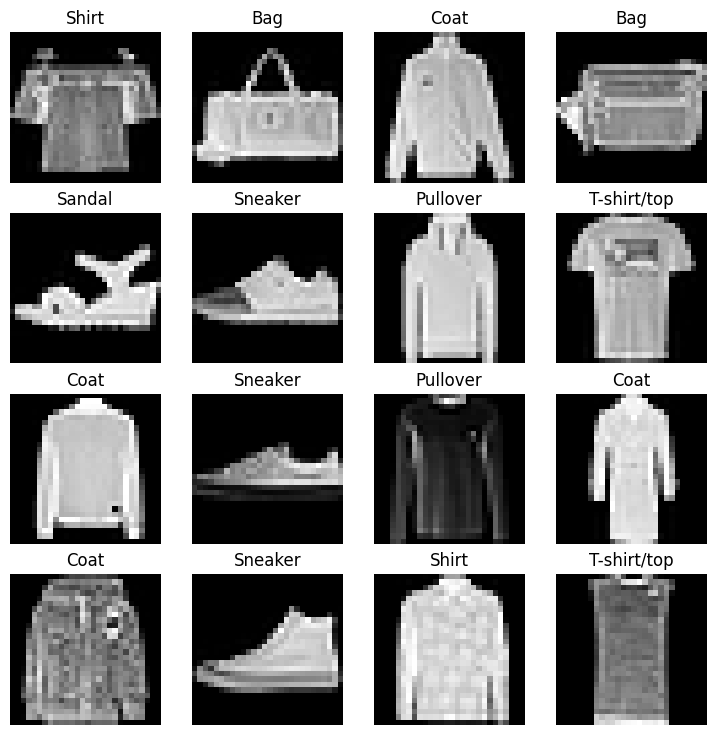

In [11]:
# torch.manual_seed(42)
fig = plt.figure(figsize = (9,9))
rows, cols = 4,4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item() # Add parentheses here
  img , label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

In [12]:
##Preparing Dara Loader
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

#Data Loader turns the dataset into a pythorn

#breaking them unto batches :

* It is more computationally efficient
* It may not be able to look stroe in memory

In [13]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)
test_dataloader = DataLoader(dataset = test_data,
                              batch_size = BATCH_SIZE,
                              shuffle = False)


In [14]:
print(f"Data Loaders : {train_dataloader, test_dataloader} ")
print(f"Length of the dataloader : {len(train_dataloader)}batches of batch size {BATCH_SIZE}")
print(f"Length of the dataloader : {len(test_dataloader)}batches of batch size {BATCH_SIZE}")

Data Loaders : (<torch.utils.data.dataloader.DataLoader object at 0x7dc6d0b96ff0>, <torch.utils.data.dataloader.DataLoader object at 0x7dc6d0b972c0>) 
Length of the dataloader : 1875batches of batch size 32
Length of the dataloader : 313batches of batch size 32


In [15]:
#show a sample
train_features_batch , train_labels_batch = next(iter(train_dataloader))

In [16]:
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size :torch.Size([1, 28, 28])
Label : 4, label size = torch.Size([])


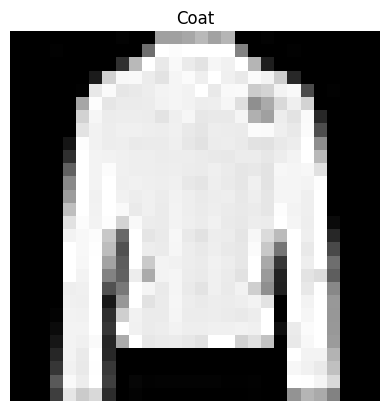

In [17]:
random_idx = torch.randint(0, len(train_features_batch), size = [1]).item()
img ,label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap = "grey")
plt.title(class_names[label])
plt.axis(False)
print(f"Image size :{img.shape}")
print(f"Label : {label}, label size = {label.shape}")


##Building a baseline model for torch vision

* When starting t build ml model, it is best practice to start with baseline model
* A baseline model is a simple model we will tryn and improve upon with subsequent model/experiment


In [18]:
flatten_model = nn.Flatten()

x = train_features_batch[0]

output = flatten_model(x) # perform forward pass

# printing out whatr happened

print(f"Shape before flattening {x.shape}")
print(f"Shape after flattening {output.shape}")


Shape before flattening torch.Size([1, 28, 28])
Shape after flattening torch.Size([1, 784])


In [44]:
# to reduce the dinmensionality of lots of features bsaically a flatten is used

class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape:int,hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape,
                  out_features = hidden_units),
        nn.Linear(in_features = hidden_units,
                  out_features = output_shape)
        )
  def forward(self, x)->torch.tensor:
          return self.layer_stack(x)

In [20]:
#creating a n instance of the model
model_0 = FashionMNISTModelV0(
    input_shape = 784,
    hidden_units= 10,
    output_shape = len(class_names)
).to("cpu")

In [21]:
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [22]:
dummy_x = torch.rand([1,1,28,28])

In [23]:
model_0(dummy_x)

tensor([[ 0.0769,  0.3548,  0.2335,  0.2894,  0.0686,  0.1479,  0.3041, -0.0209,
         -0.0249,  0.0824]], grad_fn=<AddmmBackward0>)

In [24]:
model_0.state_dict()


OrderedDict([('layer_stack.1.weight',
              tensor([[-0.0177, -0.0307, -0.0062,  ...,  0.0103, -0.0345, -0.0113],
                      [-0.0331,  0.0196, -0.0163,  ...,  0.0347,  0.0280, -0.0319],
                      [-0.0132, -0.0354,  0.0205,  ..., -0.0067,  0.0056,  0.0281],
                      ...,
                      [-0.0286, -0.0019,  0.0038,  ...,  0.0134, -0.0169, -0.0100],
                      [ 0.0024,  0.0109,  0.0337,  ..., -0.0080, -0.0122,  0.0035],
                      [-0.0354,  0.0219, -0.0176,  ..., -0.0284, -0.0052,  0.0116]])),
             ('layer_stack.1.bias',
              tensor([ 0.0270,  0.0241,  0.0140, -0.0161, -0.0235,  0.0080, -0.0105, -0.0296,
                       0.0265, -0.0136])),
             ('layer_stack.2.weight',
              tensor([[-0.2026, -0.1346, -0.0134,  0.2918, -0.2755,  0.1654,  0.1947, -0.1308,
                       -0.2282, -0.0492],
                      [-0.1748,  0.1620, -0.1144,  0.0734, -0.1824,  0.1210,  0.

#what wil our loss Function be ?
* since we have used all the multi class data our loss function will be `nn.CrossEntropyLoss()`
* Optimizer we are ging to be using is torch.optim.sgd
* we can use a torchmetrics to ise the libbrary and we could copy the finction straight in to our notebook  and  Calculate accuracy


In [25]:
##Iporting helperfuunctions.py

import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functoins already exist")
else:
  requests = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb")as f: ##this sets the permissipon of the file to write binary functions here in the file
    f.write(requests.content)  #now we write the contents inside the helper function.py file we just created





In [26]:
from helper_functions import accuracy_fn





In [27]:
#setting up loss function and optimizer
Loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)
#creating a function to time pour experiment


#creating a function to time our experiments

* Machine learning is very experimental, twi of the main thing you would want to track is the model performance etc and the second part is how fast it runs



In [28]:
from timeit import default_timer as timer
def train_time(start:float,
               end:float,
               device: torch.device = None):
  total_time = end-start
  print(f"Total Time on {device} : {total_time:.3f} seconds")
  return total_time

In [29]:
#sample on how to use the timeit funciton

start_time = timer()
"""
Some code
"""
end_time = timer()
print(f"total time : {train_time(start_time, end_time)}")

Total Time on None : 0.000 seconds
total time : 9.037399999556328e-05


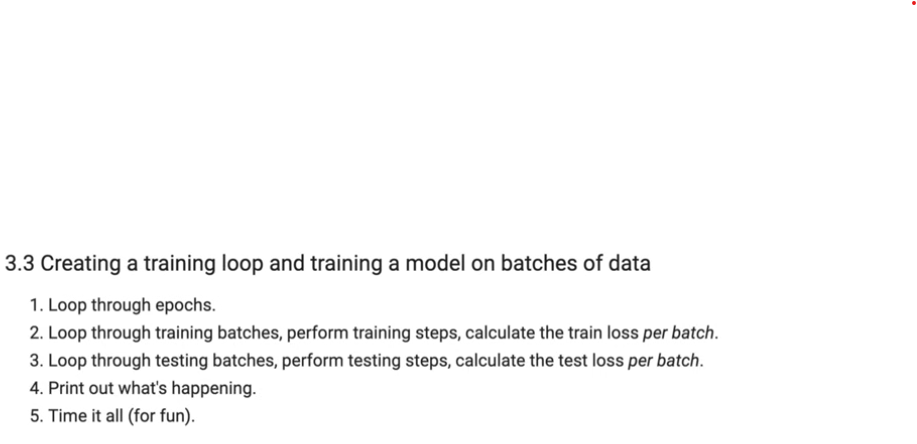

In [54]:
len(train_dataloader)

1875

In [30]:
from tqdm.auto import tqdm

#Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

#set the number of epochs
epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n------")

    ##training
    train_loss = 0
    # add a loop to loop through training loop
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        #1 do the forward pass
        y_pred = model_0(X)
        #2 calculate the loss
        loss = Loss_fn(y_pred, y)
        train_loss += loss
        #Optimizer zero grad
        optimizer.zero_grad()
        #loss backward
        loss.backward()
        #optimizer step
        optimizer.step()
        if batch %400 == 0:
          print(f"Looked at : {batch*32}/ {len(train_dataloader.dataset)} samples ")
    train_loss/=len(train_dataloader)

    #Testing
    test_loss, test_acc = 0,0
    model_0.eval()
    with torch.inference_mode():
      for X_test, y_test in test_dataloader:
        #forward pass
        test_pred = model_0(X_test) # Corrected: Use X_test here
        #calculate the accuracy
        test_loss += Loss_fn(test_pred, y_test) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
        test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

        # valculate the abg per batch
      test_loss/=len(test_dataloader)
      test_acc/=len(test_dataloader)

      print(f"\n Train Loss:{train_loss:.4f} | Test Loss {test_loss:.4f},Test acc {test_acc}")

      train_time_end_on_cpu = timer()
      toral_train_time_model_0 = train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device = str(next(model_0.parameters()).device))
      print(f"Total training time : {toral_train_time_model_0}")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0
------
Looked at : 0/ 60000 samples 
Looked at : 12800/ 60000 samples 
Looked at : 25600/ 60000 samples 
Looked at : 38400/ 60000 samples 
Looked at : 51200/ 60000 samples 

 Train Loss:0.5896 | Test Loss 0.5093,Test acc 82.23841853035144
Total Time on cpu : 9.559 seconds
Total training time : 9.559262682999986
Epoch 1
------
Looked at : 0/ 60000 samples 
Looked at : 12800/ 60000 samples 
Looked at : 25600/ 60000 samples 
Looked at : 38400/ 60000 samples 
Looked at : 51200/ 60000 samples 

 Train Loss:0.4776 | Test Loss 0.4851,Test acc 82.83746006389777
Total Time on cpu : 18.681 seconds
Total training time : 18.681395882000004
Epoch 2
------
Looked at : 0/ 60000 samples 
Looked at : 12800/ 60000 samples 
Looked at : 25600/ 60000 samples 
Looked at : 38400/ 60000 samples 
Looked at : 51200/ 60000 samples 

 Train Loss:0.4558 | Test Loss 0.4784,Test acc 83.33666134185303
Total Time on cpu : 29.683 seconds
Total training time : 29.683038065000005


In [31]:
##Make predictions and get model_ 0 results
#building multiple models
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  loss, acc =0,0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      y_pred = model(X)

      #accumulate the loss and accuracy value per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

    return {"model_name" : model.__class__.__name__,
            "model_loss" : loss.item(),
            "model_acc" : acc}

In [32]:
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=Loss_fn,
                             accuracy_fn=accuracy_fn)

  0%|          | 0/313 [00:00<?, ?it/s]

In [33]:
model_0_results.items()

dict_items([('model_name', 'FashionMNISTModelV0'), ('model_loss', 0.4783955514431), ('model_acc', 83.33666134185303)])

In [39]:
##setup some device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

In [40]:
device

'cuda'

In [41]:
!nvidia-smi

Wed Feb  4 16:18:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8             11W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
##making a new model

class

In [48]:
#Training the model 1 , and for future making a generic
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape :int, hidden_units :int, output_shape :int):
    super().__init__()
    self.non_LinearStack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )
  def forward(self, x: torch.Tensor):
    return self.non_LinearStack(x)

In [50]:
#creating the instance of model 1
model_1 = FashionMNISTModelV1(input_shape = 784, hidden_units=10, output_shape=10).to(device)

In [55]:
#model that runs in the GPU and building the one that harnesses the power of non linearity

torch.manual_seed(42)
torch.cuda.manual_seed(42)

Epochs = 3

for epoch in tqdm(range(Epochs)):
  print(f"Epoch {epoch}\n------")
  train_loss, accuracy  = 0 , 0
  model_1.train()

  for batch, (X,y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)
    y_pred = model_1(X)

    loss = Loss_fn(y_pred, y)
    train_loss += loss
    accuracy += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


  train_loss/=len(train_dataloader)
  print(f"{epoch}: train loss is {train_loss}" )





  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0
------
0: train loss is 2.3147058486938477
Epoch 1
------
1: train loss is 2.3147072792053223
Epoch 2
------
2: train loss is 2.3147060871124268
